# ST1504 CA2 Part A: CIFAR-10 Image Generation

## Objective

The objective of this project is to build and evaluate a generative deep learning model capable of generating CIFAR-10 images.

The CIFAR-10 dataset contains 60,000 colour images of size 32 × 32 pixels across 10 classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In this project, a Variational Autoencoder (VAE) / Generative Adversarial Network (GAN) will be trained to generate new images that resemble the original CIFAR-10 dataset.

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [101]:
from tensorflow.keras.datasets import cifar10
import pickle
import numpy as np
import os

dataset_path = "cifar-10-batches-py"


def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels

In [102]:
x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    batch_path = os.path.join(
        dataset_path,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    x_train_batches.append(images)
    y_train_batches.append(labels)

x_train = np.concatenate(x_train_batches)
y_train = np.concatenate(y_train_batches)

x_test, y_test = load_cifar_batch(
    os.path.join(dataset_path, "test_batch")
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


# Exploratory Data Analysis (EDA)

### Dataset Structure

The CIFAR-10 training dataset contains **50000 images**, while the testing dataset contains **10000 images**. Each image has dimensions of **32 × 32 pixels** with **3 colour channels**, representing red, green and blue (RGB).

The images are stored using the `uint8` datatype, with pixel intensities ranging from **0 to 255**. Therefore, the pixel values will need to be normalised before they are used to train the generative model.

In [103]:
# 1. Inspect the dataset structure
print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)

print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training image shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


### Class distribution analysis

The class-distribution graph shows that each of the ten classes contains **5000 training images**. This means that the CIFAR-10 training dataset is equally balanced.

As no class is overrepresented or underrepresented, techniques such as oversampling or undersampling are not required. The balanced distribution should allow the model to learn from an equal number of examples from every class.

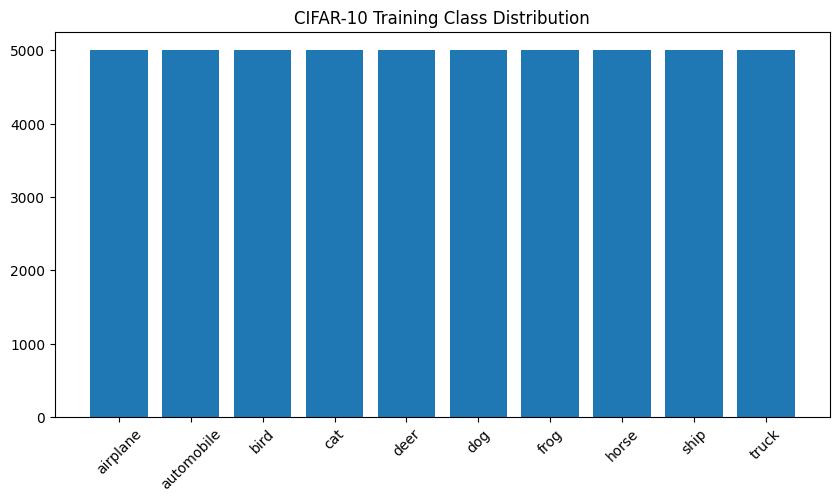

In [104]:
class_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Visual Inspection of CIFAR-10 Images

A random sample of 25 training images was displayed to understand the visual characteristics of the dataset. The images contain considerable variation in backgrounds, positions and colours.

Although the objects are generally recognisable, their small resolution of **32 × 32 pixels** means that some details appear pixelated. This suggests that the generative model will need to learn the main shapes, colours and visual patterns of each class rather than fine details.



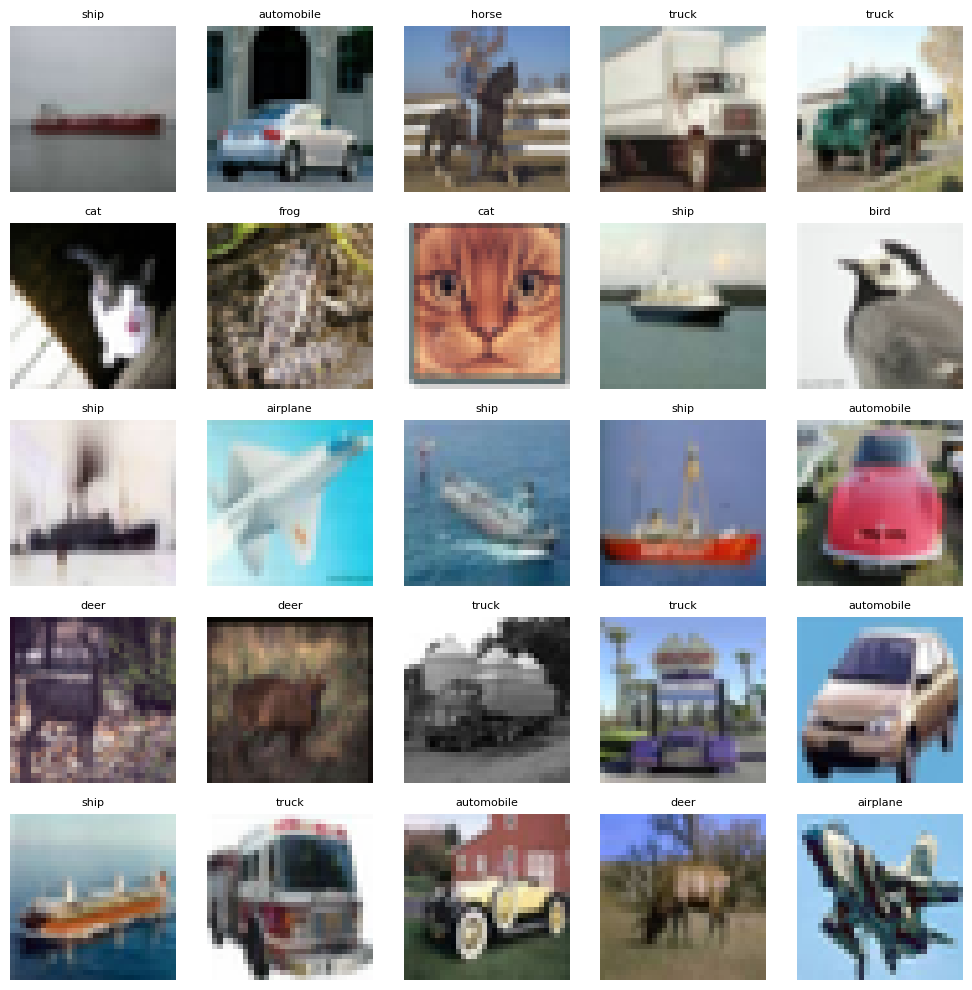

In [105]:
# 5x5 Grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, x_train.shape[0])
    ax.imshow(x_train[idx])
    ax.axis('off')
    ax.set_title(class_names[y_train[idx]], fontsize=8)
plt.tight_layout()
plt.show()

### Distribution of RGB Pixel Intensities

The histogram displays the distributions of pixel intensities for the red, green and blue channels. The three channels cover a wide range of intensity values and show overlapping distributions.

This confirms that colour information is an important feature of the dataset. Therefore, all three RGB channels will be retained instead of converting the images to grayscale for the main model.

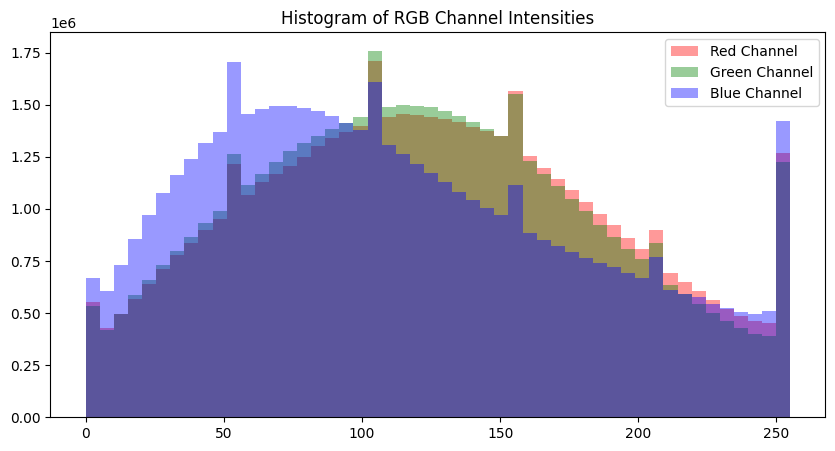

In [106]:
# RGB Histograms
plt.figure(figsize=(10, 5))
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(x_train[:, :, :, i].flatten(), bins=50, color=color, alpha=0.4, label=f'{color.capitalize()} Channel')
plt.title("Histogram of RGB Channel Intensities")
plt.legend()
plt.show()

### Data Cleaning 

The dataset was checked for missing and infinite pixel values. A total of **0 missing values** and **0 infinite values** were detected.

Therefore, no imputation or removal of images is required. The dataset can be retained in its original form before normalisation.

In [107]:
# Check for issues
print("Missing values:", np.isnan(x_train).sum())
print("Infinite values:", np.isinf(x_train).sum())


Missing values: 0
Infinite values: 0


### Variance Analysis (Inspection of Low-Contrast Images)

Pixel variance was calculated for each image to identify images with limited differences in colour or brightness. The five images with the lowest variance were then visually inspected.

The selected images appeared recognisable and mainly contained simple objects against relatively plain or uniform backgrounds. This shows that low pixel variance does not automatically indicate that an image is corrupted. Therefore, these images will be retained because they are still valid CIFAR-10 samples.

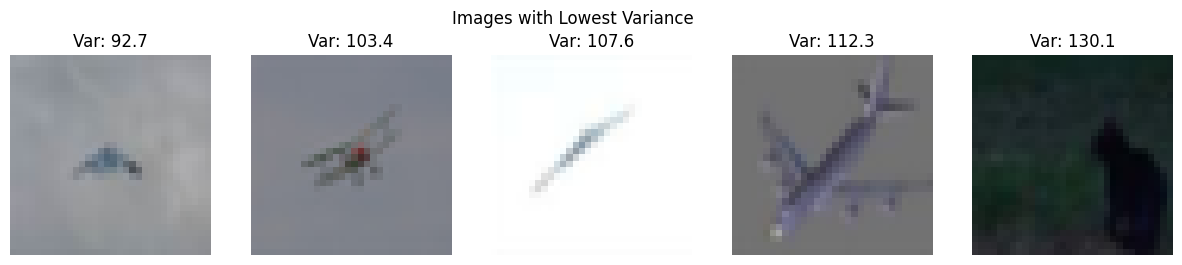

In [108]:
image_variances = x_train.var(axis=(1, 2, 3))
low_var_indices = np.argsort(image_variances)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(low_var_indices):
    axes[i].imshow(x_train[idx])
    axes[i].set_title(f"Var: {image_variances[idx]:.1f}")
    axes[i].axis('off')
plt.suptitle("Images with Lowest Variance")
plt.show()

### Comparison of Training and Testing Distributions

Each class contains **5000 training samples** and **1000 testing samples**. Both datasets therefore have the same balanced class distribution.

This makes the testing set suitable for evaluating the model because its class composition is consistent with the training set. The testing images will be kept separate and will not be used for model training.

In [109]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
print("Training counts:", train_counts)
print("Test counts:", test_counts)

Training counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Average Within-Image Pixel Variance by Class

The graph compares the average within-image pixel variance across the ten CIFAR-10 classes. The truck class has the highest average variance, while the deer class has the lowest. A higher pixel variance indicates that images within the class generally contain greater differences in colour, brightness or contrast.

However, this measurement does not directly show that trucks are harder to generate than deer. The difficulty of generating each class will be evaluated later by visually inspecting the generated images and comparing class-specific evaluation results, such as manual acceptance rates and Fréchet Inception Distance (FID).

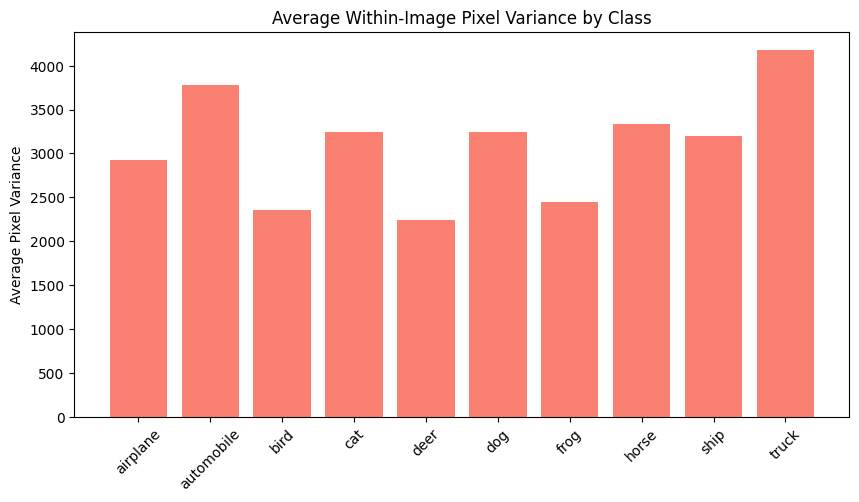

In [110]:
# Calculate variance for each image, then group by class
class_variances = []
for i in range(10):
    class_images = x_train[y_train == i]
    # Variance of each image, then mean of those variances
    avg_var = np.mean(np.var(class_images, axis=(1, 2, 3)))
    class_variances.append(avg_var)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_variances, color='salmon')
plt.title("Average Within-Image Pixel Variance by Class")
plt.ylabel("Average Pixel Variance")
plt.xticks(rotation=45)
plt.show()

### Mean Image for Each Class

A mean image was created by averaging all the training images belonging to each class. The resulting images show faint differences in the typical colours, backgrounds and object positions associated with each class. For example, the ship class generally has a blue-grey background, while vehicle classes such as automobiles and trucks contain darker areas around the lower-middle portion of the image.

However, all the mean images appear blurred because objects within the same class differ in position, size, colour, viewing angle and background. This demonstrates that there is considerable visual diversity within each class, which the generative model will need to learn.

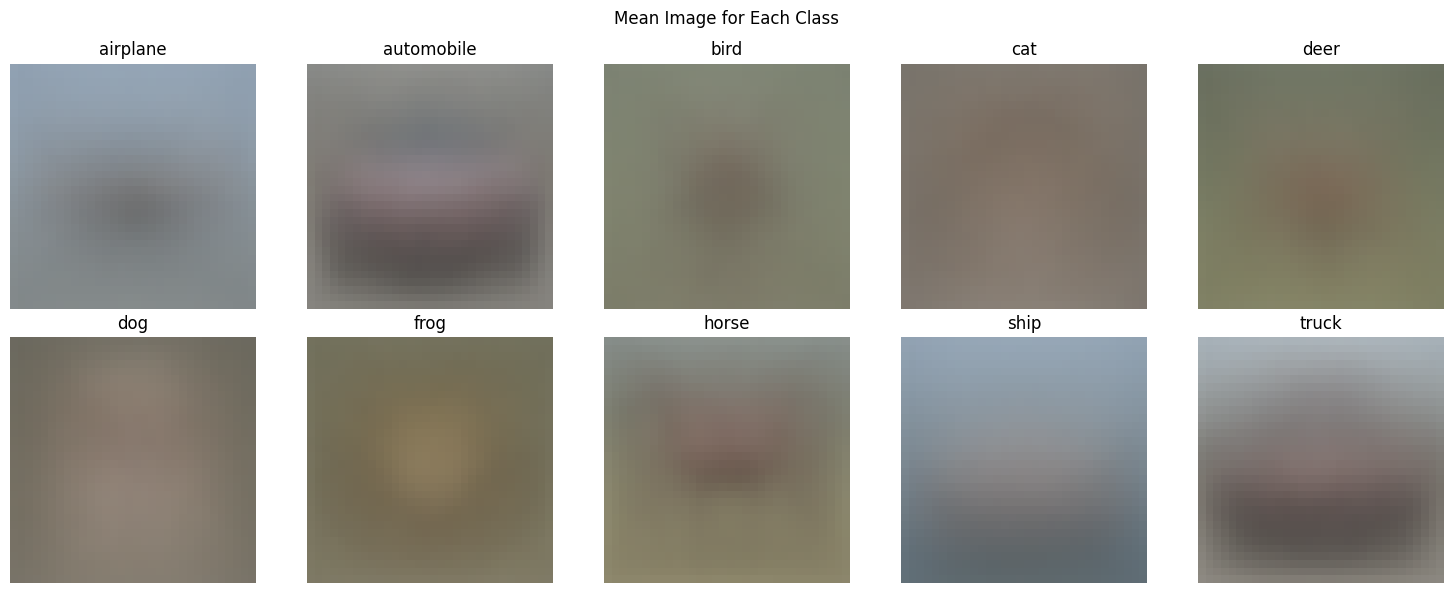

In [111]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    class_images = x_train[y_train == i]
    mean_img = np.mean(class_images, axis=0).astype('uint8')
    axes[i].imshow(mean_img)
    axes[i].set_title(class_names[i])
    axes[i].axis('off')
plt.suptitle("Mean Image for Each Class")
plt.tight_layout()
plt.show()

### RGB and Grayscale Comparison

Converting an RGB image to grayscale reduces it from three colour channels to one channel and removes its colour information. Generating grayscale images may be easier because the model has fewer pixel values and colour relationships to learn. This may also reduce the model's computational requirements.

However, colour provides useful visual information for distinguishing certain objects and backgrounds. Removing colour could make some generated objects less recognisable even if their overall shapes are preserved. Since the main task involves generating coloured CIFAR-10 images, RGB images will be retained for model training. Grayscale generation could instead be investigated as a separate experiment.

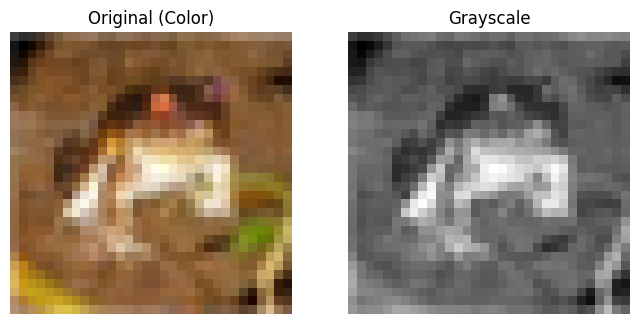

In [112]:
# Convert to grayscale by averaging channels
x_train_gray = np.mean(x_train, axis=3, keepdims=True)

# Compare shapes and visualize
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0])
plt.title("Original (Color)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_train_gray[0].reshape(32, 32), cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

### Image-Shape Consistency

All training images were found to have the same dimensions of 32 × 32 × 3. No malformed images or inconsistent image dimensions were detected.

Therefore, resizing, cropping and padding are not required before model training. Maintaining the original dimensions also ensures that no visual information is unnecessarily removed or distorted.

In [113]:
# Check for consistent image shapes
shapes = [img.shape for img in x_train]
unique_shapes = np.unique(shapes, axis=0)

if len(unique_shapes) == 1:
    print(f"All images have a consistent shape of: {unique_shapes[0]}")
else:
    print("Warning: Dataset contains inconsistent image shapes:", unique_shapes)        

All images have a consistent shape of: [32 32  3]


## Data Preprocessing

The exploratory data analysis found no missing values, corrupted images, inconsistent dimensions or class imbalance. Therefore, no image removal, resizing or class rebalancing was required.

The class labels were converted into one-dimensional integer arrays. The original training dataset was then divided into training and validation subsets using a 90:10 ratio. Stratified splitting was applied to preserve the balanced class distribution across all ten classes. The official testing dataset was kept separate for final model evaluation.

Image conversion, pixel normalisation, batching and possible augmentation will be performed during the modelling stage because their implementation depends on the selected generative architecture.

### Prepare the Labels

In [114]:
# Convert labels into one-dimensional integer arrays
y_train_processed = y_train.astype("int32").reshape(-1)
y_test_processed = y_test.astype("int32").reshape(-1)

print("Training labels:", y_train_processed.shape)
print("Testing labels:", y_test_processed.shape)
print("Label datatype:", y_train_processed.dtype)

Training labels: (50000,)
Testing labels: (10000,)
Label datatype: int32


### Create Validation Dataset

In [115]:
from sklearn.model_selection import train_test_split

x_model_train, x_val, y_model_train, y_val = train_test_split(
    x_train,
    y_train_processed,
    test_size=0.10,
    random_state=42,
    stratify=y_train_processed
)

In [116]:
print("Model-training images:", x_model_train.shape)
print("Validation images:", x_val.shape)
print("Testing images:", x_test.shape)

print("Model-training labels:", y_model_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels:", y_test_processed.shape)

print("Image datatype:", x_model_train.dtype)
print("Minimum pixel value:", x_model_train.min())
print("Maximum pixel value:", x_model_train.max())

Model-training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Model-training labels: (45000,)
Validation labels: (5000,)
Testing labels: (10000,)
Image datatype: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [117]:
print(
    "Training samples per class:",
    np.bincount(y_model_train, minlength=10)
)

print(
    "Validation samples per class:",
    np.bincount(y_val, minlength=10)
)

print(
    "Testing samples per class:",
    np.bincount(y_test_processed, minlength=10)
)

Training samples per class: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
Validation samples per class: [500 500 500 500 500 500 500 500 500 500]
Testing samples per class: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Verify the processed images

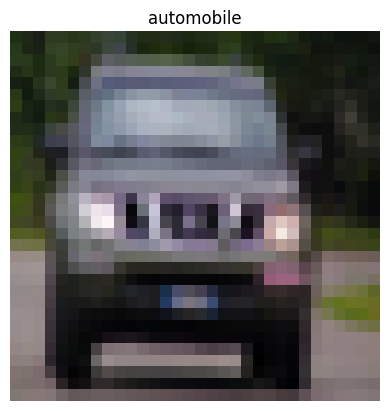

In [118]:
plt.imshow(x_model_train[0])
plt.title(class_names[y_model_train[0]])
plt.axis("off")
plt.show()

## Image Casting and Normalization (GAN)

The original CIFAR-10 images are stored using the `uint8` datatype, which represents
whole-number pixel values ranging from 0 to 255. However, `uint8` cannot represent
decimal or negative values.

Before normalization, the images are therefore cast from `uint8` to `float32`.
This allows the pixel values to be represented as decimals and negative numbers
while remaining computationally efficient for TensorFlow model training.

The images are then normalized from the original range of [0, 255] to [-1, 1].
This range matches the output of the `tanh` activation function used in the
generator's final layer. Consequently, the real training images and generated
images will share the same pixel-value range when they are compared by the
discriminator.

In [119]:
# Confirm that the original data has not been normalized
print("Original datatype:", x_model_train.dtype)
print("Original range:", x_model_train.min(), "to", x_model_train.max())

# Cast and normalize without overwriting the originals
x_model_train_norm = (
    x_model_train.astype("float32") - 127.5
) / 127.5

x_val_norm = (
    x_val.astype("float32") - 127.5
) / 127.5

x_test_norm = (
    x_test.astype("float32") - 127.5
) / 127.5

print("Normalized datatype:", x_model_train_norm.dtype)
print("Normalized range:",
      x_model_train_norm.min(),
      "to",
      x_model_train_norm.max())

Original datatype: uint8
Original range: 0 to 255
Normalized datatype: float32
Normalized range: -1.0 to 1.0


## Modelling 
### 1. Unconditional DCGAN (Baseline Model)
An unconditional DCGAN is first implemented as a baseline. The generator learns
to produce images from random latent vectors without receiving class labels,
while the discriminator learns to distinguish generated images from real
CIFAR-10 images.

This baseline will later be improved through controlled experiments while
retaining the unconditional GAN framework. Selected architectural and training
hyperparameters will be adjusted systematically to investigate their effects
on training stability and generated-image quality.

#### Batching

In [120]:
batch_size = 128

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_model_train_norm)
    .shuffle(buffer_size=10000)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

for image_batch in train_dataset.take(1):
    print("Batch shape:", image_batch.shape)
    print("Datatype:", image_batch.dtype)
    print("Minimum value:", tf.reduce_min(image_batch).numpy())
    print("Maximum value:", tf.reduce_max(image_batch).numpy())

Batch shape: (128, 32, 32, 3)
Datatype: <dtype: 'float32'>
Minimum value: -1.0
Maximum value: 1.0


#### Generator Architecture

The generator converts a random latent vector into a 32 × 32 × 3 RGB image.
A latent dimension of 100 is used to provide variation in the generated outputs.

The latent vector is projected and reshaped into 4 × 4 feature maps. Transposed
convolution layers then progressively increase the image dimensions from
4 × 4 to 8 × 8, 16 × 16 and finally 32 × 32.

Batch normalization helps stabilise training, while ReLU activation introduces
non-linearity. The final layer uses `tanh` so that generated pixel values remain
within the same [-1, 1] range as the normalized real images.

In [121]:
from tensorflow.keras import layers

latent_dim = 100

def build_generator():
    model = tf.keras.Sequential(name="generator")

    # Convert the latent vector into 4 × 4 feature maps
    model.add(
        layers.Dense(
            4 * 4 * 256,
            use_bias=False,
            input_shape=(latent_dim,)
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((4, 4, 256)))

    # 4 × 4 → 8 × 8
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 8 × 8 → 16 × 16
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 16 × 16 → 32 × 32
    model.add(
        layers.Conv2DTranspose(
            3,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()
generator.summary()


Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 4096)              409600    
                                                                 
 batch_normalization_6 (Batc  (None, 4096)             16384     
 hNormalization)                                                 
                                                                 
 re_lu_6 (ReLU)              (None, 4096)              0         
                                                                 
 reshape_2 (Reshape)         (None, 4, 4, 256)         0         
                                                                 
 conv2d_transpose_6 (Conv2DT  (None, 8, 8, 128)        524288    
 ranspose)                                                       
                                                                 
 batch_normalization_7 (Batc  (None, 8, 8, 128)        51

In [122]:
test_noise = tf.random.normal([1, latent_dim])
test_image = generator(test_noise, training=False)

print("Generated image shape:", test_image.shape)
print("Minimum value:", tf.reduce_min(test_image).numpy())
print("Maximum value:", tf.reduce_max(test_image).numpy())

Generated image shape: (1, 32, 32, 3)
Minimum value: -0.049719702
Maximum value: 0.059679378


### Discriminator Architecture

The discriminator receives a 32 × 32 × 3 image and predicts whether it is a
real CIFAR-10 image or an image created by the generator.

Three convolutional layers progressively reduce the spatial dimensions from
32 × 32 to 16 × 16, 8 × 8 and finally 4 × 4 while learning increasingly complex
visual features.

Leaky ReLU allows small negative gradients to pass through the network, reducing
the risk of inactive neurons. Dropout is included to reduce overfitting and
prevent the discriminator from becoming too dominant during GAN training.

The final dense layer produces one logit representing the real-or-fake prediction.

In [123]:
def build_discriminator():
    model = tf.keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),

            # 32 × 32 → 16 × 16
            layers.Conv2D(
                64,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(alpha=0.2),
            layers.Dropout(0.3),

            # 16 × 16 → 8 × 8
            layers.Conv2D(
                128,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(alpha=0.2),
            layers.Dropout(0.3),

            # 8 × 8 → 4 × 4
            layers.Conv2D(
                256,
                kernel_size=4,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(alpha=0.2),
            layers.Dropout(0.3),

            layers.Flatten(),
            layers.Dense(1)
        ],
        name="discriminator"
    )

    return model


discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 16, 16, 64)        3136      
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 16, 16, 64)        0         
                                                                 
 dropout_6 (Dropout)         (None, 16, 16, 64)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 8, 8, 128)         131200    
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 dropout_7 (Dropout)         (None, 8, 8, 128)         0         
                                                                 
 conv2d_8 (Conv2D)           (None, 4, 4, 256)       

In [124]:
real_prediction = discriminator(
    x_model_train_norm[:1],
    training=False
)

fake_prediction = discriminator(
    test_image,
    training=False
)

print("Real-image output shape:", real_prediction.shape)
print("Generated-image output shape:", fake_prediction.shape)

print("Real-image score:", real_prediction.numpy())
print("Generated-image score:", fake_prediction.numpy())

Real-image output shape: (1, 1)
Generated-image output shape: (1, 1)
Real-image score: [[0.02835992]]
Generated-image score: [[0.00017255]]


### GAN Training Process

A custom GAN class is used to coordinate the training of the generator and
discriminator.

During each training step, the discriminator is first trained to assign a value
of one to real CIFAR-10 images and zero to generated images. The generator is
then trained to produce images that cause the discriminator to predict that
they are real.

Separate optimizers are used because the generator and discriminator have
different objectives and their parameters must be updated independently.

In [125]:
class UnconditionalDCGAN(tf.keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()

        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim

    def compile(
        self,
        generator_optimizer,
        discriminator_optimizer,
        loss_function,
        **kwargs
    ):
        super().compile(**kwargs)

        self.generator_optimizer = generator_optimizer
        self.discriminator_optimizer = discriminator_optimizer
        self.loss_function = loss_function

        self.generator_loss_tracker = tf.keras.metrics.Mean(
            name="generator_loss"
        )

        self.discriminator_loss_tracker = tf.keras.metrics.Mean(
            name="discriminator_loss"
        )

    @property
    def metrics(self):
        return [
            self.generator_loss_tracker,
            self.discriminator_loss_tracker
        ]

    def train_step(self, real_images):

        # Allow the class to handle datasets containing only images
        if isinstance(real_images, (tuple, list)):
            real_images = real_images[0]

        current_batch_size = tf.shape(real_images)[0]

        # 1. Train the discriminator
       

        random_noise = tf.random.normal(
            shape=(current_batch_size, self.latent_dim)
        )

        generated_images = self.generator(
            random_noise,
            training=True
        )

        # Prevent generator weights from changing during this step
        generated_images = tf.stop_gradient(generated_images)

        with tf.GradientTape() as discriminator_tape:

            real_predictions = self.discriminator(
                real_images,
                training=True
            )

            fake_predictions = self.discriminator(
                generated_images,
                training=True
            )

            real_loss = self.loss_function(
                tf.ones_like(real_predictions),
                real_predictions
            )

            fake_loss = self.loss_function(
                tf.zeros_like(fake_predictions),
                fake_predictions
            )

            discriminator_loss = (real_loss + fake_loss) / 2

        discriminator_gradients = discriminator_tape.gradient(
            discriminator_loss,
            self.discriminator.trainable_variables
        )

        self.discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                self.discriminator.trainable_variables
            )
        )

    
        # 2. Train the generator
    
        random_noise = tf.random.normal(
            shape=(current_batch_size, self.latent_dim)
        )

        with tf.GradientTape() as generator_tape:

            generated_images = self.generator(
                random_noise,
                training=True
            )

            fake_predictions = self.discriminator(
                generated_images,
                training=False
            )

            # The generator wants fake images to be classified as real
            generator_loss = self.loss_function(
                tf.ones_like(fake_predictions),
                fake_predictions
            )

        generator_gradients = generator_tape.gradient(
            generator_loss,
            self.generator.trainable_variables
        )

        self.generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                self.generator.trainable_variables
            )
        )

        # Record the losses
        self.generator_loss_tracker.update_state(generator_loss)
        self.discriminator_loss_tracker.update_state(
            discriminator_loss
        )

        return {
            "generator_loss": self.generator_loss_tracker.result(),
            "discriminator_loss":
                self.discriminator_loss_tracker.result()
        }

In [126]:
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(
        self,
        latent_dim=100,
        output_directory="baseline_dcgan_progress"
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.output_directory = output_directory

        # Use fixed noise for consistent comparisons
        self.fixed_noise = tf.random.normal(
            shape=(16, latent_dim),
            seed=42
        )

        os.makedirs(output_directory, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):

        generated_images = self.model.generator(
            self.fixed_noise,
            training=False
        )

        # Convert [-1, 1] back to [0, 1] for display
        generated_images = (generated_images + 1.0) / 2.0
        generated_images = tf.clip_by_value(
            generated_images,
            0.0,
            1.0
        )

        fig, axes = plt.subplots(4, 4, figsize=(8, 8))

        for index, axis in enumerate(axes.flatten()):
            axis.imshow(generated_images[index])
            axis.axis("off")

        plt.suptitle(f"Epoch {epoch + 1}")
        plt.tight_layout()

        file_path = os.path.join(
            self.output_directory,
            f"epoch_{epoch + 1:03d}.png"
        )

        plt.savefig(file_path)
        plt.close(fig)

In [127]:
baseline_gan = UnconditionalDCGAN(
    generator=generator,
    discriminator=discriminator,
    latent_dim=latent_dim
)

baseline_gan.compile(
    generator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    discriminator_optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss_function=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    )
)

In [128]:
monitor = GANMonitor(latent_dim=latent_dim)

test_history = baseline_gan.fit(
    train_dataset,
    epochs=1,
    callbacks=[monitor]
)

351/351 [==============================] - 25s 67ms/step - generator_loss: 2.0701 - discriminator_loss: 0.4279


In [129]:
class GANCheckpoint(tf.keras.callbacks.Callback):
    def __init__(
        self,
        output_directory="baseline_dcgan_weights",
        save_interval=5
    ):
        super().__init__()

        self.output_directory = output_directory
        self.save_interval = save_interval

        os.makedirs(output_directory, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):

        completed_epoch = epoch + 1

        if completed_epoch % self.save_interval == 0:

            generator_path = os.path.join(
                self.output_directory,
                f"generator_epoch_{completed_epoch:03d}.h5"
            )

            discriminator_path = os.path.join(
                self.output_directory,
                f"discriminator_epoch_{completed_epoch:03d}.h5"
            )

            self.model.generator.save_weights(generator_path)
            self.model.discriminator.save_weights(
                discriminator_path
            )

            print(
                f"Saved checkpoint for epoch {completed_epoch}"
            )

#### Full Baseline Training

Following the successful one-epoch test, the baseline DCGAN is trained for a
total of 50 epochs. Generated-image samples are monitored throughout training,
while generator and discriminator weights are saved every five epochs for
subsequent evaluation.

In [130]:
checkpoint = GANCheckpoint(
    output_directory="baseline_dcgan_weights",
    save_interval=5
)

baseline_history = baseline_gan.fit(
    train_dataset,
    initial_epoch=1,
    epochs=50,
    callbacks=[monitor, checkpoint]
)

Epoch 2/50
351/351 [==============================] - 24s 68ms/step - generator_loss: 1.6841 - discriminator_loss: 0.5158
Epoch 3/50
351/351 [==============================] - 25s 72ms/step - generator_loss: 1.4236 - discriminator_loss: 0.5715
Epoch 4/50
351/351 [==============================] - 26s 73ms/step - generator_loss: 1.6208 - discriminator_loss: 0.5257
Epoch 5/50
351/351 [==============================] - 24s 68ms/step - generator_loss: 1.5398 - discriminator_loss: 0.5314
Epoch 6/50
351/351 [==============================] - 24s 69ms/step - generator_loss: 1.4964 - discriminator_loss: 0.5563
Epoch 7/50
351/351 [==============================] - 25s 71ms/step - generator_loss: 1.4662 - discriminator_loss: 0.5788
Epoch 8/50
351/351 [==============================] - 25s 72ms/step - generator_loss: 1.4769 - discriminator_loss: 0.5665
Epoch 9/50
351/351 [==============================] - 25s 72ms/step - generator_loss: 1.5908 - discriminator_loss: 0.5548
Epoch 10/50
351/351 [===

In [132]:
baseline_gan.generator.save_weights(
    "baseline_generator_final.h5"
)

baseline_gan.discriminator.save_weights(
    "baseline_discriminator_final.h5"
)

print("Final baseline weights saved.")

Final baseline weights saved.


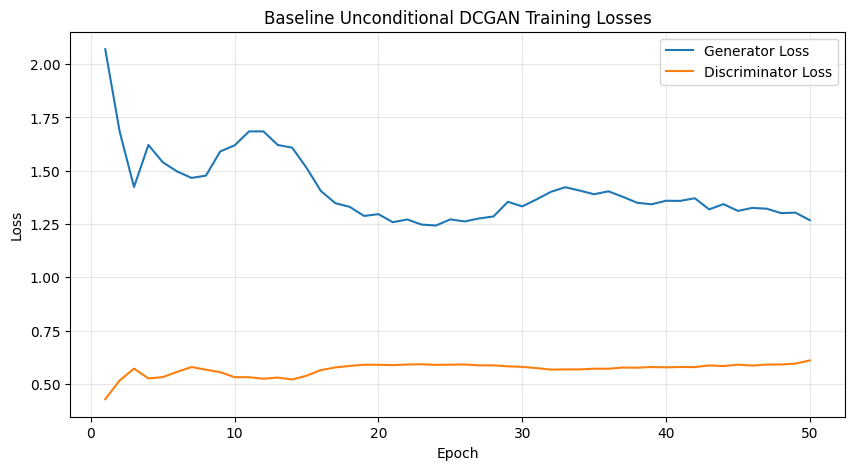

In [133]:
generator_losses = (
    test_history.history["generator_loss"]
    + baseline_history.history["generator_loss"]
)

discriminator_losses = (
    test_history.history["discriminator_loss"]
    + baseline_history.history["discriminator_loss"]
)

epoch_numbers = range(1, len(generator_losses) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epoch_numbers,
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    epoch_numbers,
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Unconditional DCGAN Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Generated images after Epoch 1


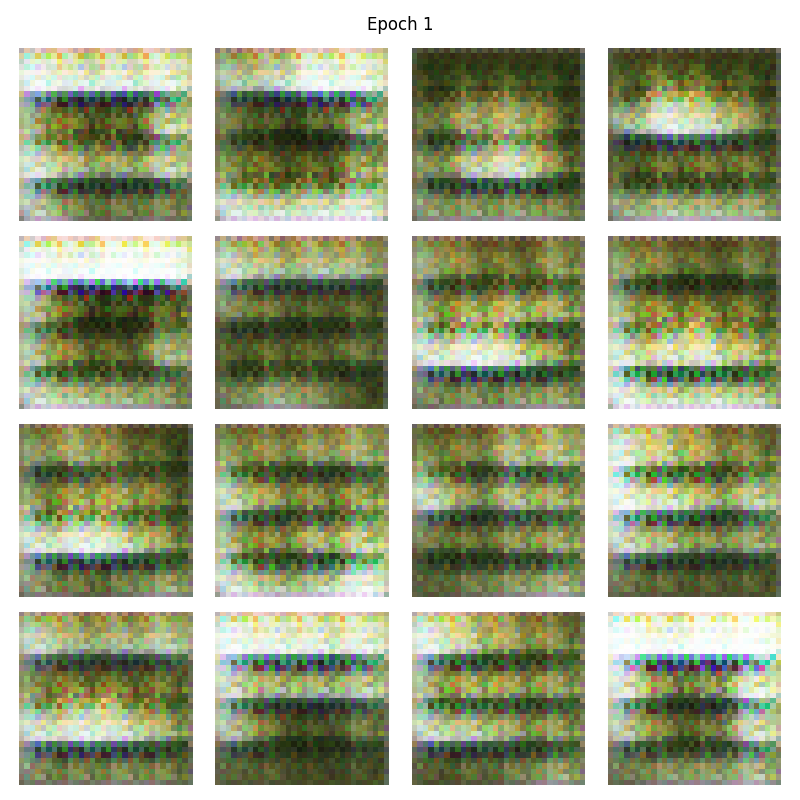

Generated images after Epoch 10


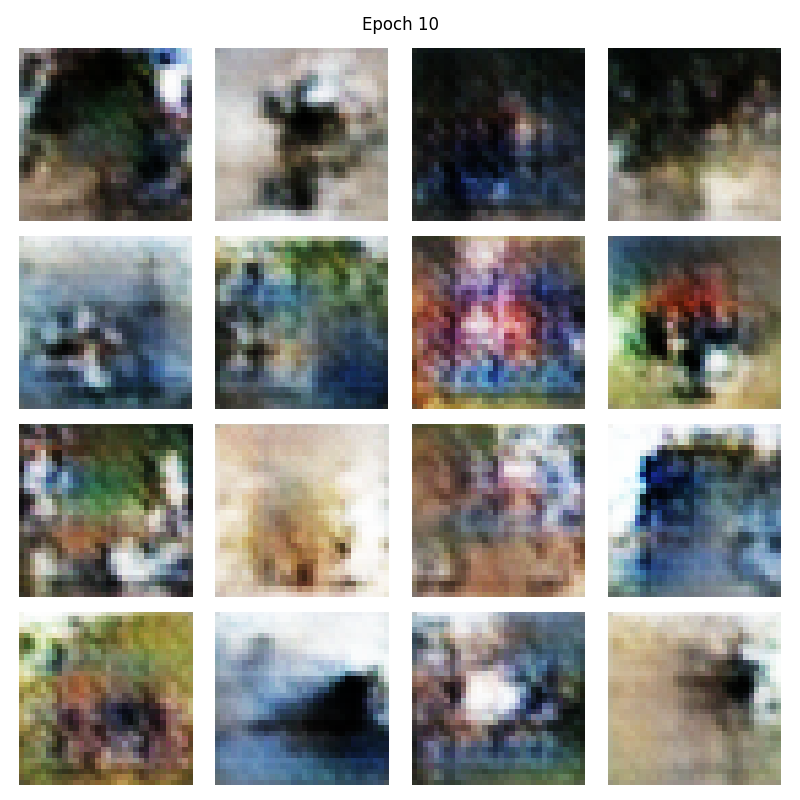

Generated images after Epoch 25


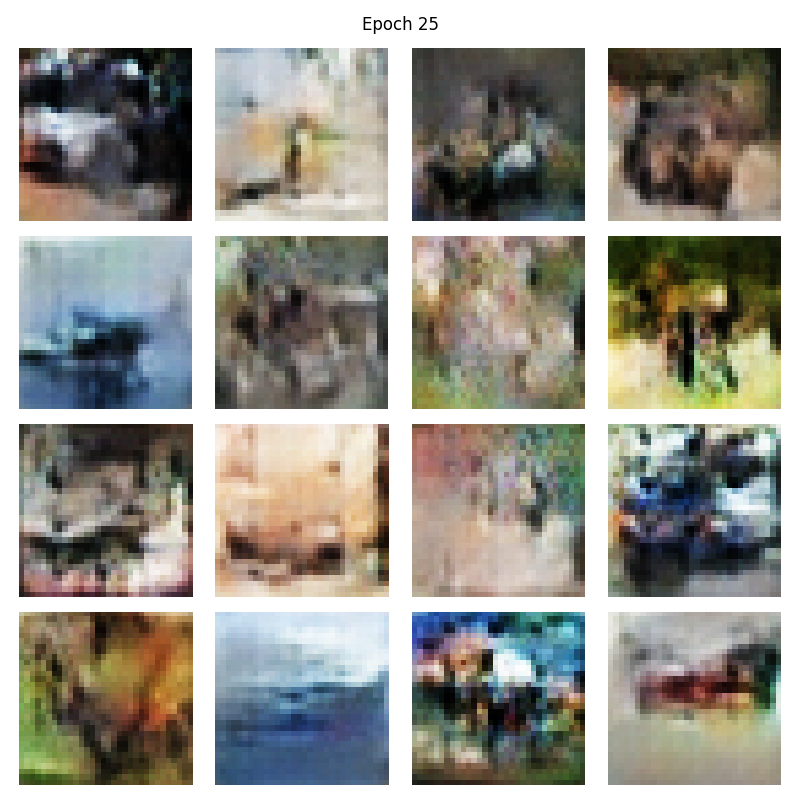

Generated images after Epoch 40


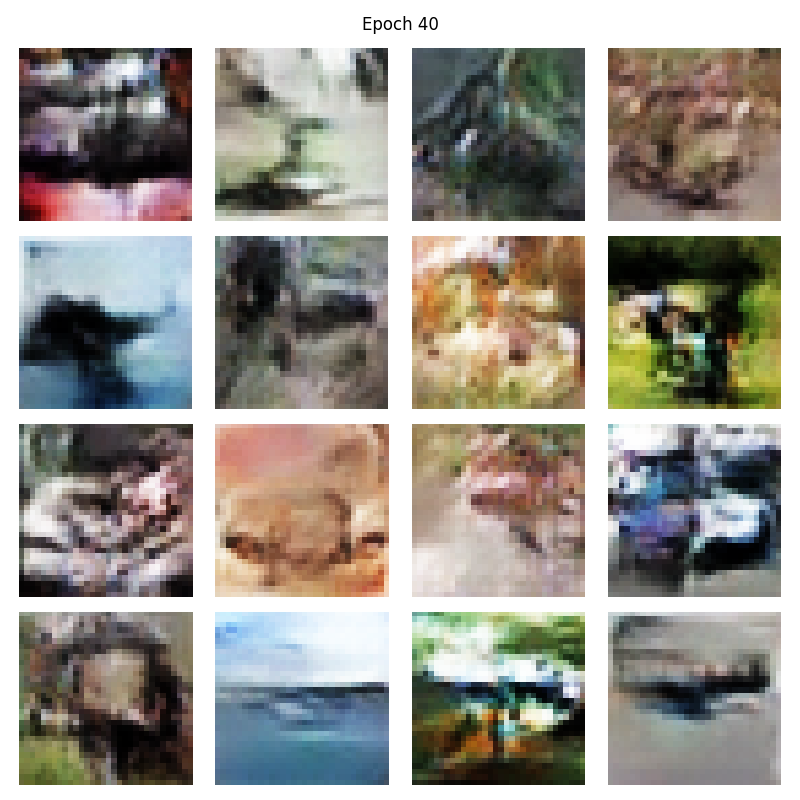

Generated images after Epoch 50


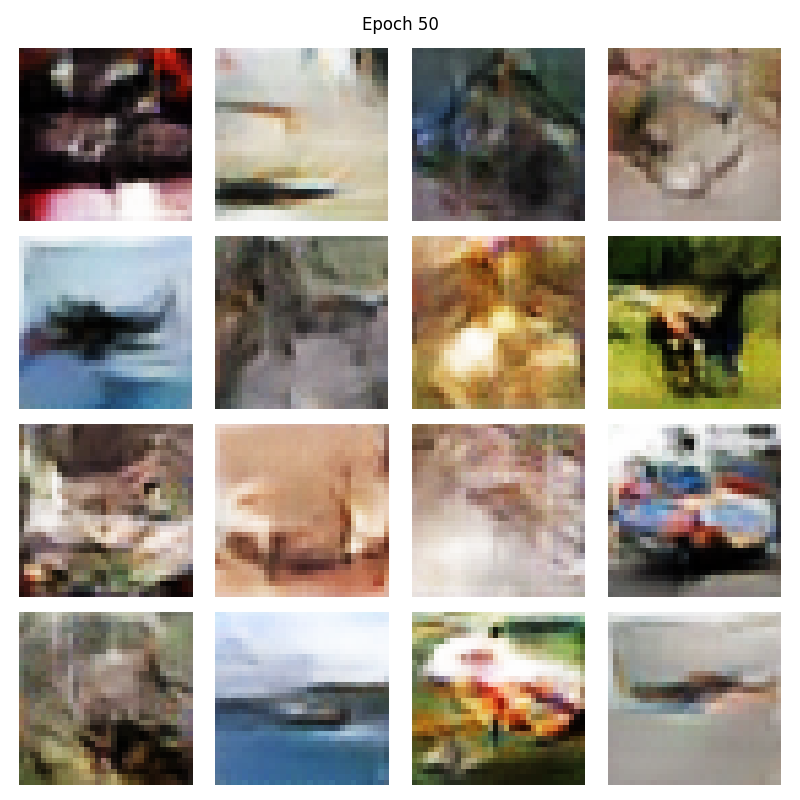

In [134]:
from IPython.display import display
from PIL import Image

selected_epochs = [1, 10, 25, 40, 50]

for epoch in selected_epochs:
    image_path = (
        f"baseline_dcgan_progress/"
        f"epoch_{epoch:03d}.png"
    )

    print(f"Generated images after Epoch {epoch}")
    display(Image.open(image_path))